# Demo: DeepHit Competing Risks

This notebook implements the **static DeepHit** model for competing risks survival analysis on AAPL limit-order-book data.

**Three competing events** (from `src/domain/enums.py`):
| Code | Event |
|------|-------|
| 0 | CENSORED |
| 1 | FAVORABLE_FILL |
| 2 | TOXIC_FILL |
| 3 | RUNAWAY |

**Pipeline:**
1. Load pre-built dataset (`data/datasets/`)
2. Flatten LOB entry representation to 1-D feature vector
3. Train / val / test split
4. Discretize durations with PyCox `LabTransDiscreteTime`
5. Train static DeepHit with 3 competing risk heads
6. Predict cause-specific CIFs
7. Evaluate with concordance index and Brier score

Reference implementation: `notebooks/reference_implementations/S6.1.4_DeepHit_competing.ipynb`

## 1. Import Required Libraries

In [175]:
from __future__ import annotations

import sys
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models.data import pair_rank_mat
from pycox.evaluation import EvalSurv

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.domain.enums import EventType

%matplotlib inline
print("PyTorch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.10.0+cpu
Device: cpu


## 2. Load and Explore the Dataset

The dataset is generated by `OrderTracker.process_stream` and labeled by `ExecutionCompetingRisksLabeler`.  
Key columns:
- **`duration_s`** – continuous lifetime of the virtual order (seconds)
- **`event_type`** – integer from `EventType` enum (0=censored, 1/2/3 = competing events)
- **`entry_representation`** – LOB snapshot sequence `(lookback, 2W+1)` stored as a nested list

In [176]:
DATASET_PATH = PROJECT_ROOT / "data" / "datasets" / "dataset_XNAS_ITCH_AAPL_mbo_20251101_20251201.parquet"

df_raw = pd.read_parquet(DATASET_PATH)
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nEvent type distribution:")
print(df_raw["event_type"].value_counts().sort_index().rename({v: v.name for v in EventType}))

Shape: (18998, 19)

Columns: ['order_id', 'entry_time', 'duration_s', 'event', 'status_reason', 'price', 'side', 'volume', 'order_type', 'best_bid_at_entry', 'best_ask_at_entry', 'best_bid_at_post_trade', 'best_ask_at_post_trade', 'entry_representation', 'event_type', 'event_time_bin', 'post_trade_adverse_move_bps', 'post_trade_spread_bps', 'post_trade_recorded']

Event type distribution:
event_type
CENSORED            259
FAVORABLE_FILL    17805
TOXIC_FILL          639
RUNAWAY             295
Name: count, dtype: int64


Duration stats (seconds):
count    18998.000000
mean        12.817245
std         62.492314
min          0.000100
25%          0.377299
50%          1.273819
75%          4.669365
max       3661.369907
Name: duration_s, dtype: float64


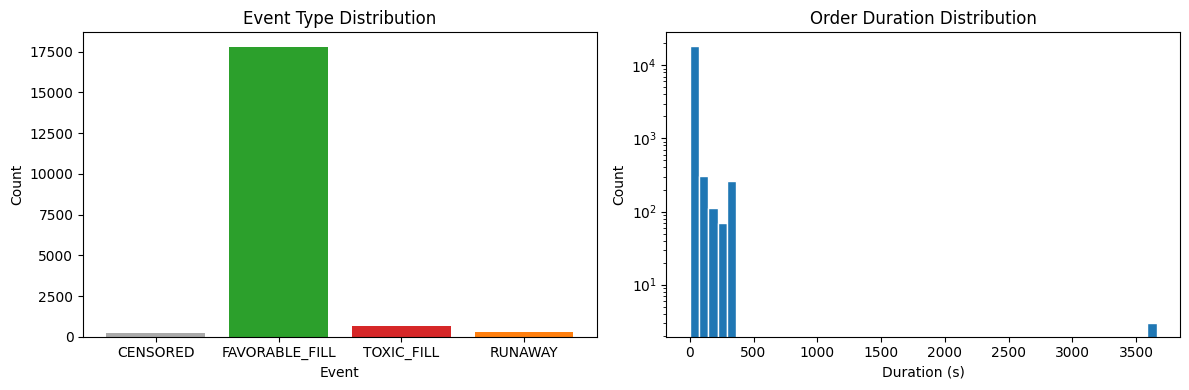

In [177]:
print("Duration stats (seconds):")
print(df_raw["duration_s"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Event distribution
event_counts = df_raw["event_type"].value_counts().sort_index()
event_labels = [EventType(k).name for k in event_counts.index]
axes[0].bar(event_labels, event_counts.values, color=["#aaa", "#2ca02c", "#d62728", "#ff7f0e"])
axes[0].set_title("Event Type Distribution")
axes[0].set_xlabel("Event")
axes[0].set_ylabel("Count")

# Duration distribution (log scale)
axes[1].hist(df_raw["duration_s"], bins=50, color="#1f77b4", edgecolor="white")
axes[1].set_title("Order Duration Distribution")
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("Count")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 3. Preprocess the Dataset

### 3a. Feature Extraction

Each `entry_representation` is a `(lookback, 2W+1)` matrix (lookback LOB snapshots, 41 tick-offset features each).  
We flatten it into a 1-D feature vector of length `lookback × (2W+1)`.  
Values are normalised per-feature (zero-mean, unit variance) using training-set statistics.

In [178]:
def extract_features(df: pd.DataFrame) -> np.ndarray:
    """Flatten entry_representation (lookback, 2W+1) -> 1-D float32 array per sample.

    entry_representation is stored as a list of rows (each row is itself a list),
    so we convert row-by-row before stacking, matching the pattern in demo_dataset_generation_one_day.ipynb.
    """
    rows = []
    for rep in df["entry_representation"]:
        arr = np.stack([np.asarray(row, dtype=np.float32) for row in rep])  # (lookback, 2W+1)
        rows.append(arr.ravel())
    return np.stack(rows, axis=0)   # (N, lookback*(2W+1))


X_all = extract_features(df_raw)
Y_all = df_raw["duration_s"].values.astype(np.float32)      # continuous durations (seconds)
D_all = df_raw["event_type"].values.astype(np.int64)         # 0=censored, 1/2/3=competing

print(f"Feature matrix shape: {X_all.shape} - (N, lookback x (2W+1))")
print(f"Duration vector shape: {Y_all.shape}")
print(f"Event vector shape: {D_all.shape}")

Feature matrix shape: (18998, 820) - (N, lookback x (2W+1))
Duration vector shape: (18998,)
Event vector shape: (18998,)


### 3b. Train / Validation / Test Split

In [179]:
SEED = 4718

# Day-boundary temporal split
# We extract the trading date for each order and choose the split points
# so that each partition starts cleanly at the beginning of a new day.

entry_ns = df_raw["entry_time"].values
dates = pd.to_datetime(entry_ns, unit="ns", utc=True).tz_convert("America/New_York").normalize()

unique_days = sorted(dates.unique())
n_days = len(unique_days)
print(f"Dataset spans {n_days} trading days: {unique_days[0].date()} to {unique_days[-1].date()}")

# Pick the day boundaries nearest to the 70 / 85 percentile of total rows
n = len(df_raw)
target_train_end = int(n * 0.70)
target_val_end   = int(n * 0.85)

# Cumulative row counts at the END of each day
day_end_idx = [(dates <= d).sum() - 1 for d in unique_days]   # last row index of each day

def _best_day_cut(target_row: int) -> int:
    """Return the index of the day whose END row is closest to target_row."""
    return min(range(n_days), key=lambda i: abs(day_end_idx[i] - target_row))

train_day_idx = _best_day_cut(target_train_end)
val_day_idx   = _best_day_cut(target_val_end)
train_day_idx = min(train_day_idx, n_days - 3)
val_day_idx   = max(train_day_idx + 1, min(val_day_idx, n_days - 2))

train_end = day_end_idx[train_day_idx] + 1
val_end   = day_end_idx[val_day_idx]   + 1

idx = np.arange(n)
train_mask = idx < train_end
val_mask   = (idx >= train_end) & (idx < val_end)
test_mask  = idx >= val_end

X_train, Y_train, D_train = X_all[train_mask], Y_all[train_mask], D_all[train_mask]
X_val,   Y_val,   D_val   = X_all[val_mask],   Y_all[val_mask],   D_all[val_mask]
X_test,  Y_test,  D_test  = X_all[test_mask],  Y_all[test_mask],  D_all[test_mask]

train_days = unique_days[:train_day_idx + 1]
val_days   = unique_days[train_day_idx + 1 : val_day_idx + 1]
test_days  = unique_days[val_day_idx + 1:]

print(f"Train: {X_train.shape[0]} samples over {len(train_days)} days "
      f"({train_days[0].date()} to {train_days[-1].date()})")
print(f"Val: {X_val.shape[0]} samples over {len(val_days)} days "
      f"({val_days[0].date()} to {val_days[-1].date()})")
print(f"Test: {X_test.shape[0]} samples over {len(test_days)} days "
      f"({test_days[0].date()} to {test_days[-1].date()})")

Dataset spans 19 trading days: 2025-11-03 to 2025-11-28
Train: 13000 samples over 13 days (2025-11-03 to 2025-11-19)
Val: 3000 samples over 3 days (2025-11-20 to 2025-11-24)
Test: 2998 samples over 3 days (2025-11-25 to 2025-11-28)


### 3c. Feature Normalisation

Standardise each feature using training-set mean and standard deviation (prevents data leakage).

In [180]:
# feat_mean = X_train.mean(axis=0)
# feat_std  = X_train.std(axis=0) + 1e-8    # avoid division by zero for constant columns

# X_train_np = ((X_train - feat_mean) / feat_std).astype(np.float32)
# X_val_np   = ((X_val   - feat_mean) / feat_std).astype(np.float32)
# X_test_np  = ((X_test  - feat_mean) / feat_std).astype(np.float32)

X_train_np = X_train.astype(np.float32)
X_val_np   = X_val.astype(np.float32)
X_test_np  = X_test.astype(np.float32)

### 3d. Discretise Continuous Durations

Following the reference implementation, we use a custom `LabTransform` built on PyCox's `LabTransDiscreteTime`.  
Durations are discretised via quantile-based binning. Only uncensored events inform the grid construction.

> **Note on event codes:** Our `event_type` uses 0 = censored, 1/2/3 = competing events — consistent with PyCox's multi-event convention where `event > 0` marks any critical event.

In [181]:
class LabTransform(LabTransDiscreteTime):
    """Extends LabTransDiscreteTime to handle 3 competing risks (events 1, 2, 3)."""
    def transform(self, durations, events):
        durations, is_event = super().transform(durations, events > 0)
        events[is_event == 0] = 0
        return durations, events.astype("int64")


NUM_TIME_STEPS = 20

label_transform = LabTransform(NUM_TIME_STEPS, scheme="quantiles")

Y_train_disc, D_train_disc = label_transform.fit_transform(Y_train.copy(), D_train.copy())
Y_val_disc,   D_val_disc   = label_transform.transform(Y_val.copy(),   D_val.copy())

time_grid = label_transform.cuts
output_steps = len(time_grid)

print(f"Requested time steps : {NUM_TIME_STEPS}")
print(f"Actual time steps    : {output_steps}")
print(f"Time grid (seconds)  : {np.round(time_grid, 3)}")

Requested time steps : 20
Actual time steps    : 20
Time grid (seconds)  : [0.00000e+00 5.30000e-02 1.11000e-01 1.85000e-01 2.75000e-01 3.77000e-01
 4.97000e-01 6.35000e-01 7.94000e-01 1.00400e+00 1.25400e+00 1.55000e+00
 1.98100e+00 2.53100e+00 3.38900e+00 4.62700e+00 6.87000e+00 1.14800e+01
 2.51600e+01 3.00665e+02]


### 3e. Build PyTorch Datasets

In [182]:
def make_tensors(X_np, Y_disc_np, D_disc_np):
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    Y = torch.tensor(Y_disc_np, dtype=torch.int64, device=device)
    D = torch.tensor(D_disc_np, dtype=torch.int32, device=device)
    return X, Y, D


X_train_t, Y_train_t, D_train_t = make_tensors(X_train_np, Y_train_disc, D_train_disc)
X_val_t, Y_val_t, D_val_t = make_tensors(X_val_np, Y_val_disc, D_val_disc)

train_data = list(zip(X_train_t, Y_train_t, D_train_t))
val_data = list(zip(X_val_t, Y_val_t, D_val_t))

print(f"Train tensor: X={tuple(X_train_t.shape)}, Y={tuple(Y_train_t.shape)}, D={tuple(D_train_t.shape)}")
print(f"Val tensor: X={tuple(X_val_t.shape)}, Y={tuple(Y_val_t.shape)}, D={tuple(D_val_t.shape)}")

Train tensor: X=(13000, 820), Y=(13000,), D=(13000,)
Val tensor: X=(3000, 820), Y=(3000,), D=(3000,)


## 4. Define the DeepHit Architecture

The static DeepHit for competing risks uses a **shared MLP backbone** followed by a single output layer of shape `(num_critical_events × num_time_steps)`.  
PyCox's `DeepHit` model reshapes this into `(batch, K, T)` where `K=3` competing events and `T` is the number of discrete time steps, then applies a softmax over all `K×T` entries jointly so the outputs represent a joint PMF over `(cause, time)`.

$\text{Loss} = \alpha \cdot L_\text{likelihood} + (1−\alpha) \cdot L_\text{ranking}$
- **L_likelihood**: negative log-likelihood from the joint PMF
- **L_ranking**: pair-wise ranking loss (controlled by `sigma`) that penalises ordering violations among uncensored subjects

## 5. Configure Training Parameters

In [252]:
# Hyperparameters
NUM_COMPETING_EVENTS = 3
EVENT_NAMES = ["FAVORABLE_FILL", "TOXIC_FILL", "RUNAWAY"]

# Network
NUM_HIDDEN_1   = 256
NUM_HIDDEN_2   = 128
DROPOUT        = 0.2

# DeepHit loss
ALPHA          = 0.5
SIGMA          = 0.1

# Class-imbalance control (event codes: 0=CENSORED, 1=FAVORABLE, 2=TOXIC, 3=RUNAWAY)
TOXIC_CLASS_BOOST   = 1.01
RUNAWAY_CLASS_BOOST = 0.7

# Optimisation
LEARNING_RATE  = 1e-4
BATCH_SIZE     = 256
NUM_EPOCHS     = 100

print("Configuration:")
for k, v in {
    "Competing events": NUM_COMPETING_EVENTS,
    "Hidden (1,2)": (NUM_HIDDEN_1, NUM_HIDDEN_2),
    "Dropout": DROPOUT,
    "Alpha (LH weight)": ALPHA,
    "Sigma": SIGMA,
    "Toxic class boost": TOXIC_CLASS_BOOST,
    "Runaway class boost": RUNAWAY_CLASS_BOOST,
    "LR": LEARNING_RATE,
    "Batch size": BATCH_SIZE,
    "Epochs": NUM_EPOCHS,
}.items():
    print(f"  {k:<22}: {v}")

Configuration:
  Competing events      : 3
  Hidden (1,2)          : (256, 128)
  Dropout               : 0.2
  Alpha (LH weight)     : 0.5
  Sigma                 : 0.1
  Toxic class boost     : 1.01
  Runaway class boost   : 0.7
  LR                    : 0.0001
  Batch size            : 256
  Epochs                : 100


In [253]:
torch.manual_seed(SEED)

class DeepHitMLP(nn.Module):
    """
    Shared-bottom MLP for DeepHit with competing risks.

    Output shape: (batch, K, T) where K = num competing events,
    T = number of discrete time steps.  PyCox's DeepHit applies a
    joint softmax over K*T entries to form the cause-time PMF.
    """
    def __init__(
        self,
        num_features: int,
        num_events: int,
        num_time_steps: int,
        hidden_1: int,
        hidden_2: int,
        dropout: float,
    ):
        super().__init__()
        self.num_events     = num_events
        self.num_time_steps = num_time_steps

        self.net = nn.Sequential(
            nn.Linear(num_features, hidden_1),
            nn.BatchNorm1d(hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_1, hidden_2),
            nn.BatchNorm1d(hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_2, num_events * num_time_steps),
        ).to(device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x)                               # (B, K*T)
        return out.view(x.size(0), self.num_events, -1) # (B, K, T)


num_input_features = X_train_t.size(1)

base_net = DeepHitMLP(
    num_features=num_input_features,
    num_events=NUM_COMPETING_EVENTS,
    num_time_steps=output_steps,
    hidden_1=NUM_HIDDEN_1,
    hidden_2=NUM_HIDDEN_2,
    dropout=DROPOUT,
).to(device)

deephit_model = DeepHit(
    base_net,
    alpha=ALPHA,
    sigma=SIGMA,
    device=device,
    duration_index=time_grid,
)
deephit_loss = deephit_model.loss

total_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print(f"Input features : {num_input_features}")
print(f"Output (K, T)  : ({NUM_COMPETING_EVENTS}, {output_steps})")
print(f"Trainable params: {total_params:,}")

Input features : 820
Output (K, T)  : (3, 20)
Trainable params: 251,580


## 6. Train the DeepHit Model

Training uses mini-batch gradient descent with a **class-imbalance-aware loss**.  
The pair-rank matrix (`pair_rank_mat`) needed for the ranking loss is computed per batch on the CPU.  
Model parameters from the epoch with the **lowest validation loss** are retained.

### Weighted NLL for Class Imbalance

The standard DeepHit loss is:

$$\mathcal{L} = \alpha \cdot \mathcal{L}_\text{NLL} + (1-\alpha) \cdot \mathcal{L}_\text{rank}$$

The NLL term is modified to apply **inverse-frequency weights** per sample:

$$\mathcal{L}_\text{NLL} = -\frac{\sum_i w_{d_i} \log \ell_i}{\sum_i w_{d_i}}, \quad w_k = \frac{1}{\#\{i : d_i = k\}}$$

This upweights gradient contributions from rare events (RUNAWAY, TOXIC_FILL) without resampling or duplicating data rows.  
The ranking loss is left unweighted to preserve its calibration properties.

In [254]:
import torch.nn.functional as F

# Inverse-frequency class weights + targeted class boosts
event_codes  = D_train_disc.astype(int)
class_counts = np.bincount(event_codes)

base_weights = 1.0 / np.maximum(class_counts, 1)
class_boosts = np.ones_like(base_weights, dtype=np.float32)

# event code mapping: 0=CENSORED, 1=FAVORABLE, 2=TOXIC, 3=RUNAWAY
if len(class_boosts) > 2:
    class_boosts[2] = TOXIC_CLASS_BOOST
if len(class_boosts) > 3:
    class_boosts[3] = RUNAWAY_CLASS_BOOST

class_weights_np = (base_weights * class_boosts).astype(np.float32)
class_weights_np = class_weights_np / class_weights_np.mean()  # keep loss scale stable
class_weights_t = torch.tensor(class_weights_np, device=device)

print("Class counts and training weights (training set):")
for code, cnt in enumerate(class_counts):
    label = EventType(code).name if code in EventType._value2member_map_ else str(code)
    bw = float(base_weights[code]) if code < len(base_weights) else float("nan")
    boost = float(class_boosts[code]) if code < len(class_boosts) else 1.0
    fw = float(class_weights_np[code]) if code < len(class_weights_np) else float("nan")
    print(
        f"  {label:<20}: {cnt:>5}  base={bw:.6f}  boost={boost:.2f}  final={fw:.6f}"
    )


def weighted_deephit_loss(phi, idx_durations, events, rank_mat):
    """
    DeepHit competing-risks loss with inverse-frequency weighting on the NLL term.

    Rare-event samples receive a proportionally larger gradient signal without
    altering the data distribution or duplicating rows.

    Parameters
    ----------
    phi          : (B, K, T)  model logits (pre-softmax)
    idx_durations: (B,)       discrete time indices
    events       : (B,)       event codes - 0=censored, 1..K=competing events
    rank_mat     : (B, B)     pair-rank matrix from pycox.models.data.pair_rank_mat
    """
    B, K, T = phi.shape

    # Joint PMF over (cause, time) via softmax over K*T
    pmf = F.softmax(phi.view(B, -1), dim=1).view(B, K, T) # (B, K, T)
    overall_cif = pmf.sum(dim=1).cumsum(dim=1).clamp(max=1.0 - 1e-8) # (B, T)
    surv = 1.0 - overall_cif # (B, T)

    t_idx = idx_durations.long().clamp(0, T - 1) # (B,)
    d_int = events.long() # (B,)
    arange = torch.arange(B, device=phi.device)

    # Weighted NLL
    # Uncensored (d > 0): log PMF of the actual (cause, time) cell
    k_idx = (d_int - 1).clamp(0, K - 1) # 0-indexed cause
    pmf_at_event = pmf[arange, k_idx, t_idx].clamp(min=1e-8) # (B,)

    # Censored (d = 0): log overall survival at censoring time
    surv_at_cens = surv[arange, t_idx].clamp(min=1e-8) # (B,)

    is_event = (d_int > 0).float()
    log_lkl  = is_event * pmf_at_event.log() + (1.0 - is_event) * surv_at_cens.log()

    # Scale each sample's contribution by its event-type weight
    sample_w     = class_weights_t[d_int] # (B,)
    nll_weighted = -(sample_w * log_lkl).sum() / sample_w.sum()

    # Ranking loss (standard, unweighted)
    diag_cif = overall_cif[arange, t_idx] # CIF_i(t_i), shape (B,)
    cif_j_at_ti = overall_cif.T[t_idx] # (B, B)

    diff      = diag_cif.unsqueeze(1) - cif_j_at_ti # (B, B)
    rm_float  = rank_mat.float()
    n_pairs   = rm_float.sum().clamp(min=1.0)
    rank_loss = (rm_float * torch.exp(-diff / SIGMA)).sum() / n_pairs

    return ALPHA * nll_weighted + (1.0 - ALPHA) * rank_loss

train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1
)

train_losses, val_losses = [], []
best_val_loss  = float("inf")
best_params    = None
best_epoch_idx = None


def _epoch_loss(loader, net, loss_fn):
    """Compute mean weighted DeepHit loss over a data loader."""
    net.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for X_b, Y_b, D_b in loader:
            out  = net(X_b)
            rm   = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
            rm_t = torch.tensor(rm, dtype=torch.int, device=device)
            bs   = X_b.size(0)
            total += float(loss_fn(out, Y_b, D_b, rm_t)) * bs
            n     += bs
    return total / n


for epoch in range(NUM_EPOCHS):
    base_net.train()
    for X_b, Y_b, D_b in train_loader:
        out  = base_net(X_b)
        rm   = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
        rm_t = torch.tensor(rm, dtype=torch.int, device=device)
        loss = weighted_deephit_loss(out, Y_b, D_b, rm_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    tr_loss = _epoch_loss(train_loader, base_net, weighted_deephit_loss)
    vl_loss = _epoch_loss(val_loader,   base_net, weighted_deephit_loss)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    scheduler.step()

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_epoch_idx = epoch
        best_params    = deepcopy(base_net.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  train={tr_loss:.4f}  val={vl_loss:.4f}")

base_net.load_state_dict(best_params)
print(f"\nBest val loss {best_val_loss:.4f} at epoch {best_epoch_idx + 1}")

Class counts and training weights (training set):
  CENSORED            :    55  base=0.018182  boost=1.00  final=2.607391
  FAVORABLE_FILL      : 12441  base=0.000080  boost=1.00  final=0.011527
  TOXIC_FILL          :   406  base=0.002463  boost=1.01  final=0.356750
  RUNAWAY             :    98  base=0.010204  boost=0.70  final=1.024332
Epoch  10/100  train=2.4278  val=2.4634
Epoch  20/100  train=2.3437  val=2.4313
Epoch  30/100  train=2.2919  val=2.4151
Epoch  40/100  train=2.2559  val=2.4018
Epoch  50/100  train=2.2473  val=2.4016
Epoch  60/100  train=2.2443  val=2.3995
Epoch  70/100  train=2.2402  val=2.3995
Epoch  80/100  train=2.2338  val=2.4074
Epoch  90/100  train=2.2160  val=2.3987
Epoch 100/100  train=2.2222  val=2.4019

Best val loss 2.3947 at epoch 89


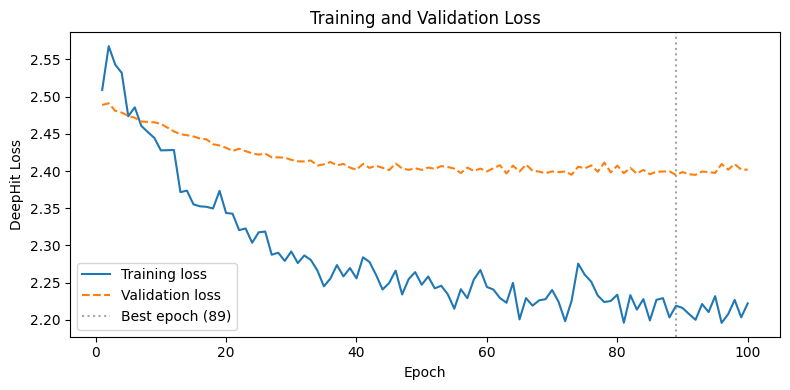

In [255]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Training loss")
plt.plot(epochs, val_losses, "--", label="Validation loss")
plt.axvline(best_epoch_idx + 1, color="grey", linestyle=":", alpha=0.7, label=f"Best epoch ({best_epoch_idx+1})")
plt.xlabel("Epoch")
plt.ylabel("DeepHit Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Evaluate Model Performance

### 7a. Predict CIFs on the Test Set

`deephit_model.predict_cif` returns an array of shape `(K, T, N)` where:
- `K` = number of competing events (3)
- `T` = discrete time steps
- `N` = number of test samples

In [256]:
base_net.eval()

# cif shape: (K, T, N_test)
cif_test = deephit_model.predict_cif(
    X_test_np.astype("float32"),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
)

print(f"CIF array shape: {cif_test.shape}   (K=events, T=time_steps, N=test_samples)")
print(f"CIF range: [{cif_test.min():.4f}, {cif_test.max():.4f}]")
print(f"\nFor test sample 0 at t={time_grid[-1]:.1f}s:")
for k, name in enumerate(EVENT_NAMES):
    print(f"  CIF({name}) = {cif_test[k, -1, 0]:.4f}")

CIF array shape: (3, 20, 2998)   (K=events, T=time_steps, N=test_samples)
CIF range: [0.0000, 0.8222]

For test sample 0 at t=300.7s:
  CIF(FAVORABLE_FILL) = 0.4080
  CIF(TOXIC_FILL) = 0.3486
  CIF(RUNAWAY) = 0.2276


In [257]:
# End-outcome accuracy on non-censored test orders only (event_type in {1,2,3})
non_censored_mask = (D_test > 0)
n_non_censored = int(non_censored_mask.sum())

if n_non_censored == 0:
    print("No non-censored samples in test set; accuracy is undefined.")
else:
    # Final-horizon CIF per cause: shape (K, N_non_censored)
    final_cif_nc = cif_test[:, -1, non_censored_mask]

    # Predicted cause is argmax over the 3 competing events (mapped back to 1/2/3)
    pred_event_nc = final_cif_nc.argmax(axis=0) + 1
    true_event_nc = D_test[non_censored_mask]

    outcome_acc_non_censored = float((pred_event_nc == true_event_nc).mean())

    print(f"Non-censored test samples: {n_non_censored}")
    print(f"End-outcome accuracy (non-censored only): {outcome_acc_non_censored:.4f}")

    print("\nPer-event recall (among true non-censored events):")
    for event_code, event_name in enumerate(EVENT_NAMES, start=1):
        m = (true_event_nc == event_code)
        if m.sum() == 0:
            print(f"  {event_name:<20}: n=0")
        else:
            rec = (pred_event_nc[m] == event_code).mean()
            print(f"  {event_name:<20}: recall={rec:.4f}  (n={int(m.sum())})")

Non-censored test samples: 2799
End-outcome accuracy (non-censored only): 0.7824

Per-event recall (among true non-censored events):
  FAVORABLE_FILL      : recall=0.8208  (n=2478)
  TOXIC_FILL          : recall=0.0364  (n=165)
  RUNAWAY             : recall=0.9615  (n=156)


In [258]:
# Additional classification diagnostics on non-censored outcomes (1/2/3)
if n_non_censored == 0:
    print("No non-censored samples in test set; diagnostics are undefined.")
else:
    event_codes = np.array([1, 2, 3], dtype=int)
    event_names = np.array(EVENT_NAMES)

    # Confusion matrix (rows=true, cols=pred)
    cm = pd.crosstab(
        pd.Series(true_event_nc, name="True"),
        pd.Series(pred_event_nc, name="Pred"),
        rownames=["True"],
        colnames=["Pred"],
        dropna=False,
    ).reindex(index=event_codes, columns=event_codes, fill_value=0)

    # Per-class metrics
    recalls = []
    precisions = []
    f1s = []

    print("Per-class precision / recall / F1 (non-censored only):")
    for code, name in zip(event_codes, event_names):
        tp = int(cm.loc[code, code])
        fp = int(cm[code].sum() - tp)
        fn = int(cm.loc[code].sum() - tp)

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = (
            2 * precision * recall / (precision + recall)
            if (not np.isnan(precision) and not np.isnan(recall) and (precision + recall) > 0)
            else np.nan
        )

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

        p_txt = f"{precision:.4f}" if not np.isnan(precision) else "nan"
        r_txt = f"{recall:.4f}" if not np.isnan(recall) else "nan"
        f1_txt = f"{f1:.4f}" if not np.isnan(f1) else "nan"
        support = int(cm.loc[code].sum())
        print(f"  {name:<20}  precision={p_txt}  recall={r_txt}  f1={f1_txt}  (n={support})")

    # Macro / balanced summaries
    macro_precision = float(np.nanmean(precisions))
    macro_recall = float(np.nanmean(recalls))
    macro_f1 = float(np.nanmean(f1s))
    balanced_accuracy = macro_recall

    print("\nSummary metrics (non-censored only):")
    print(f"  Accuracy          : {outcome_acc_non_censored:.4f}")
    print(f"  Balanced Accuracy : {balanced_accuracy:.4f}")
    print(f"  Macro Precision   : {macro_precision:.4f}")
    print(f"  Macro Recall      : {macro_recall:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}")

    cm_named = cm.copy()
    cm_named.index = EVENT_NAMES
    cm_named.columns = EVENT_NAMES
    print("\nConfusion matrix (rows=true, cols=pred):")
    display(cm_named)

Per-class precision / recall / F1 (non-censored only):
  FAVORABLE_FILL        precision=0.9382  recall=0.8208  f1=0.8756  (n=2478)
  TOXIC_FILL            precision=0.0432  recall=0.0364  f1=0.0395  (n=165)
  RUNAWAY               precision=0.3049  recall=0.9615  f1=0.4630  (n=156)

Summary metrics (non-censored only):
  Accuracy          : 0.7824
  Balanced Accuracy : 0.6062
  Macro Precision   : 0.4287
  Macro Recall      : 0.6062
  Macro F1          : 0.4593

Confusion matrix (rows=true, cols=pred):


,FAVORABLE_FILL,TOXIC_FILL,RUNAWAY
FAVORABLE_FILL,2034,131,313
TOXIC_FILL,130,6,29
RUNAWAY,4,2,150


### 7b. Time-Dependent Concordance Index (Antolini et al., 2005)

PyCox's `EvalSurv` computes the time-dependent concordance index using `1 - CIF(event)` as the "survival" curve.  
We evaluate each competing cause separately, treating the other events as censoring.

In [259]:
print("Time-dependent Concordance Index (Antolini) per competing event:")

ctd_scores = {}
for k, name in enumerate(EVENT_NAMES):
    event_code = k + 1

    one_minus_cif_df = pd.DataFrame(
        1 - cif_test[k, :, :],
        index=time_grid,
    )

    eval_sksurv = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv="km",
    )

    ctd = eval_sksurv.concordance_td("antolini")
    ctd_scores[name] = ctd
    print(f"  {name:<20}: C-td = {ctd:.4f}")

print(f"\n  Macro-average C-td : {np.mean(list(ctd_scores.values())):.4f}")

Time-dependent Concordance Index (Antolini) per competing event:
  FAVORABLE_FILL      : C-td = 0.6102
  TOXIC_FILL          : C-td = 0.6266
  RUNAWAY             : C-td = 0.7390

  Macro-average C-td : 0.6586


### 7c. Cause-Specific Brier Score (Graf et al., 1999)

The competing-risk Brier score at horizon $\tau$ is:

$$
\text{BS}^k(\tau) = \frac{1}{n} \sum_{i=1}^{n} w_i(\tau) \cdot \hat{e}_i^k(\tau)^2
$$

where the residual $\hat{e}_i^k(\tau)$ and IPCW weights $w_i(\tau)$ depend on whether the subject experienced cause $k$, another cause, or is still at risk at $\tau$.  
We estimate the censoring survival function via the Kaplan–Meier estimator on the training set.

In [260]:
import lifelines

# Fit censoring KMF on training set (event indicator = 1 when censored)
censoring_kmf = lifelines.KaplanMeierFitter()
censoring_kmf.fit(Y_train, event_observed=(D_train == 0))


def brier_competing(
    cif_at_tau: np.ndarray,      # (N_test,) CIF values at time tau
    Y_test_np: np.ndarray,       # continuous durations
    D_test_np: np.ndarray,       # event codes (0=censored, 1/2/3)
    event_of_interest: int,      # 1, 2 or 3
    tau: float,                  # evaluation time horizon
    cens_kmf,                    # fitted censoring KaplanMeierFitter
) -> float:
    n = len(Y_test_np)
    residuals = np.zeros(n)
    for i in range(n):
        t_i = Y_test_np[i]
        d_i = D_test_np[i]
        if t_i > tau:
            w = cens_kmf.predict(tau)
            residuals[i] = cif_at_tau[i] ** 2 / (w + 1e-15)
        else:
            w = cens_kmf.predict(t_i)
            if d_i == event_of_interest:
                residuals[i] = (1.0 - cif_at_tau[i]) ** 2 / (w + 1e-15)
            elif d_i != 0:   # another competing event
                residuals[i] = cif_at_tau[i] ** 2 / (w + 1e-15)
            # censored at or before tau: zero contribution
    return float(residuals.mean())


# Evaluate at the 25th, 50th, 75th percentile of test durations
time_grid_test = np.unique(Y_test)
eval_time_pcts = [0.25, 0.50, 0.75]
eval_times = [time_grid_test[int(p * len(time_grid_test))] for p in eval_time_pcts]

print("Cause-Specific Brier Scores:")
print("-" * 65)
for k, name in enumerate(EVENT_NAMES):
    event_code = k + 1
    for tau in eval_times:
        # Interpolate toCIF value at tau using the training time grid
        tidx = int(np.argmin(np.abs(tau - time_grid)))
        cif_at_tau = cif_test[k, tidx, :]   # (N_test,)
        bs = brier_competing(cif_at_tau, Y_test, D_test, event_code, tau, censoring_kmf)
        print(f"  {name:<20}  τ={tau:>8.2f}s   BS = {bs:.4f}")

Cause-Specific Brier Scores:
-----------------------------------------------------------------
  FAVORABLE_FILL        τ=    0.73s   BS = 0.1763
  FAVORABLE_FILL        τ=    2.79s   BS = 0.2776
  FAVORABLE_FILL        τ=   14.13s   BS = 0.3275
  TOXIC_FILL            τ=    0.73s   BS = 0.0359
  TOXIC_FILL            τ=    2.79s   BS = 0.0701
  TOXIC_FILL            τ=   14.13s   BS = 0.1016
  RUNAWAY               τ=    0.73s   BS = 0.0238
  RUNAWAY               τ=    2.79s   BS = 0.0460
  RUNAWAY               τ=   14.13s   BS = 0.0569


## 8. Visualise Cause-Specific CIF Curves

### 8a. CIFs for Individual Test Orders

For each competing event we plot the CIF as a function of time for several randomly chosen test orders.  
We also indicate each order's actual outcome.

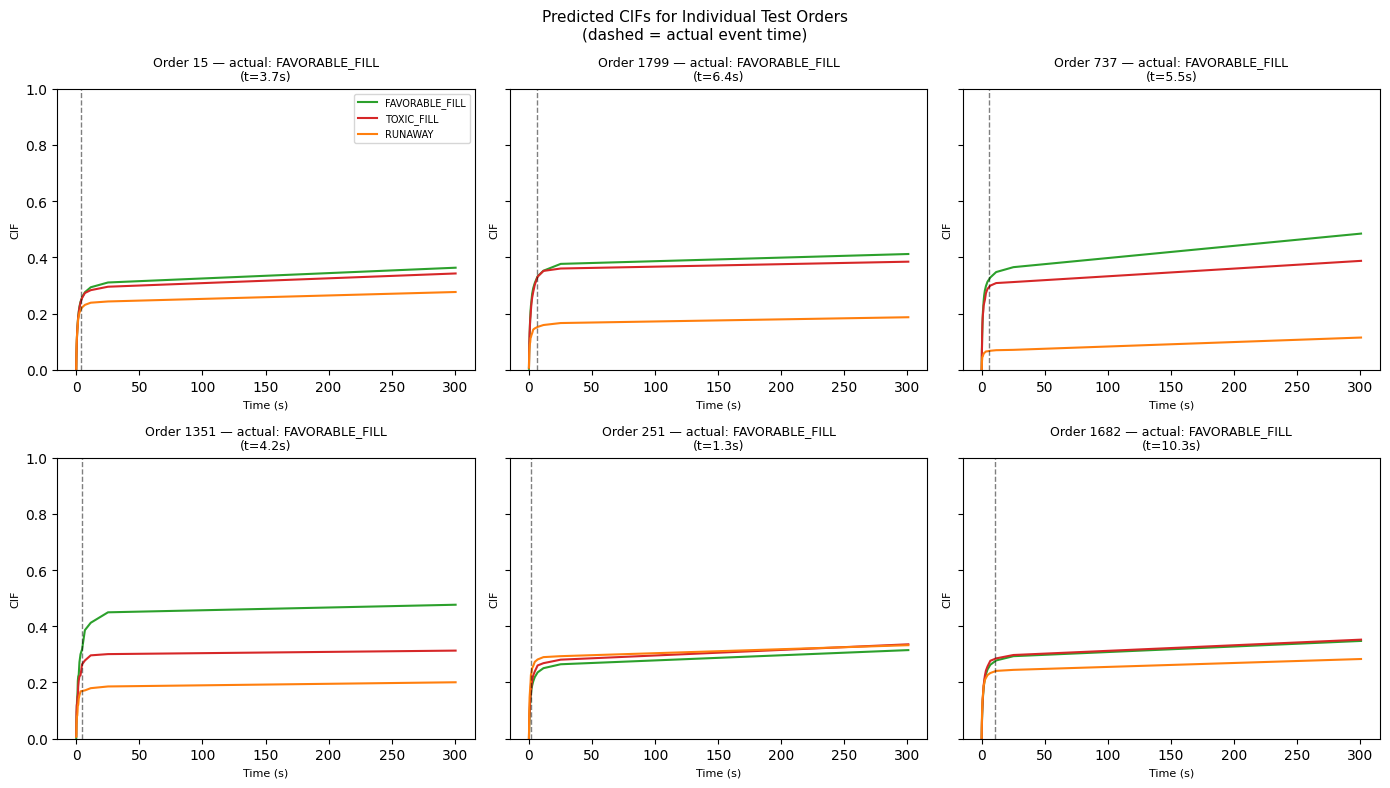

In [261]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(Y_test), size=min(6, len(Y_test)), replace=False)

colors = ["#2ca02c", "#d62728", "#ff7f0e"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.ravel()

for ax_idx, sample_idx in enumerate(sample_indices):
    true_event = D_test[sample_idx]
    true_time  = Y_test[sample_idx]

    for k, (name, color) in enumerate(zip(EVENT_NAMES, colors)):
        ax = axes[ax_idx]
        ax.plot(time_grid, cif_test[k, :, sample_idx], label=name, color=color)

    event_label = EventType(true_event).name if true_event in EventType._value2member_map_ else "CENSORED"
    ax.axvline(true_time, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"Order {sample_idx} — actual: {event_label}\n(t={true_time:.1f}s)", fontsize=9)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("CIF", fontsize=8)
    ax.set_ylim(0, 1)
    if ax_idx == 0:
        ax.legend(fontsize=7)

plt.suptitle("Predicted CIFs for Individual Test Orders\n(dashed = actual event time)", fontsize=11)
plt.tight_layout()
plt.show()

### 8b. Average CIFs Across the Test Set

The **population-average CIF** shows how the overall incidence of each event evolves over time.  
The **overall survival function** is `1 - Σ_k CIF_k(t)`.

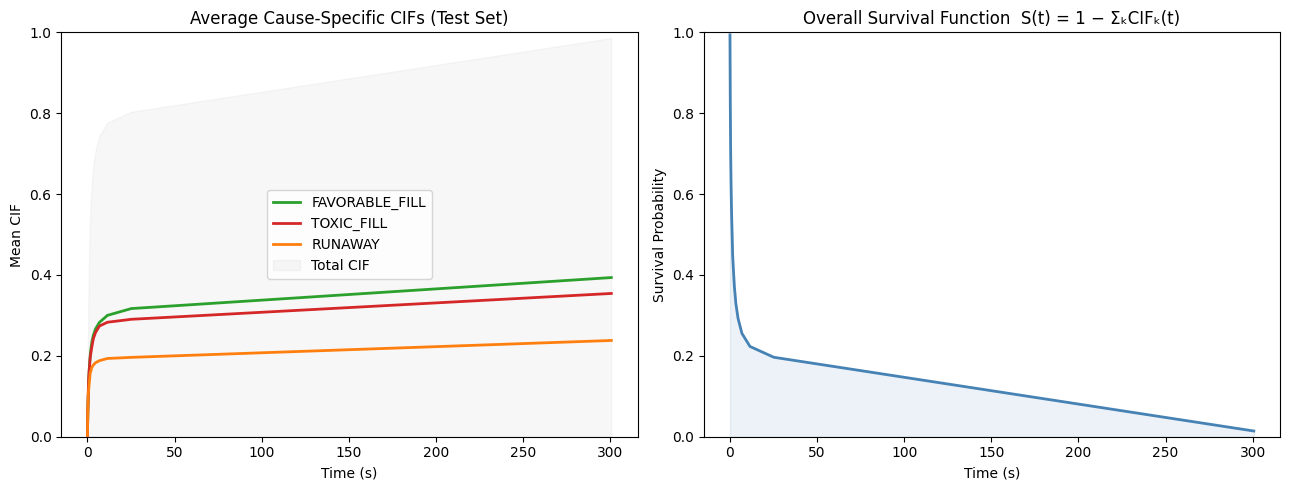

In [262]:
# cif_test shape: (K, T, N) → mean over N
mean_cif = cif_test.mean(axis=2)   # (K, T)
overall_survival = 1.0 - mean_cif.sum(axis=0)   # (T,)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: cause-specific average CIFs
ax = axes[0]
for k, (name, color) in enumerate(zip(EVENT_NAMES, colors)):
    ax.plot(time_grid, mean_cif[k], label=name, color=color, linewidth=2)
ax.fill_between(time_grid, 0, mean_cif.sum(axis=0), alpha=0.06, color="grey", label="Total CIF")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean CIF")
ax.set_ylim(0, 1)
ax.set_title("Average Cause-Specific CIFs (Test Set)")
ax.legend()

# Right: overall survival
ax = axes[1]
ax.plot(time_grid, overall_survival, color="steelblue", linewidth=2)
ax.fill_between(time_grid, 0, overall_survival, alpha=0.10, color="steelblue")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Survival Probability")
ax.set_ylim(0, 1)
ax.set_title("Overall Survival Function  S(t) = 1 − ΣₖCIFₖ(t)")

plt.tight_layout()
plt.show()

### 8c. CIF Heatmaps — Population Stratified by Actual Outcome

Stratify the test set by the actual event outcome and visualise the mean CIF surface across events and time. This reveals whether the model assigns higher predicted incidence to the correct cause.

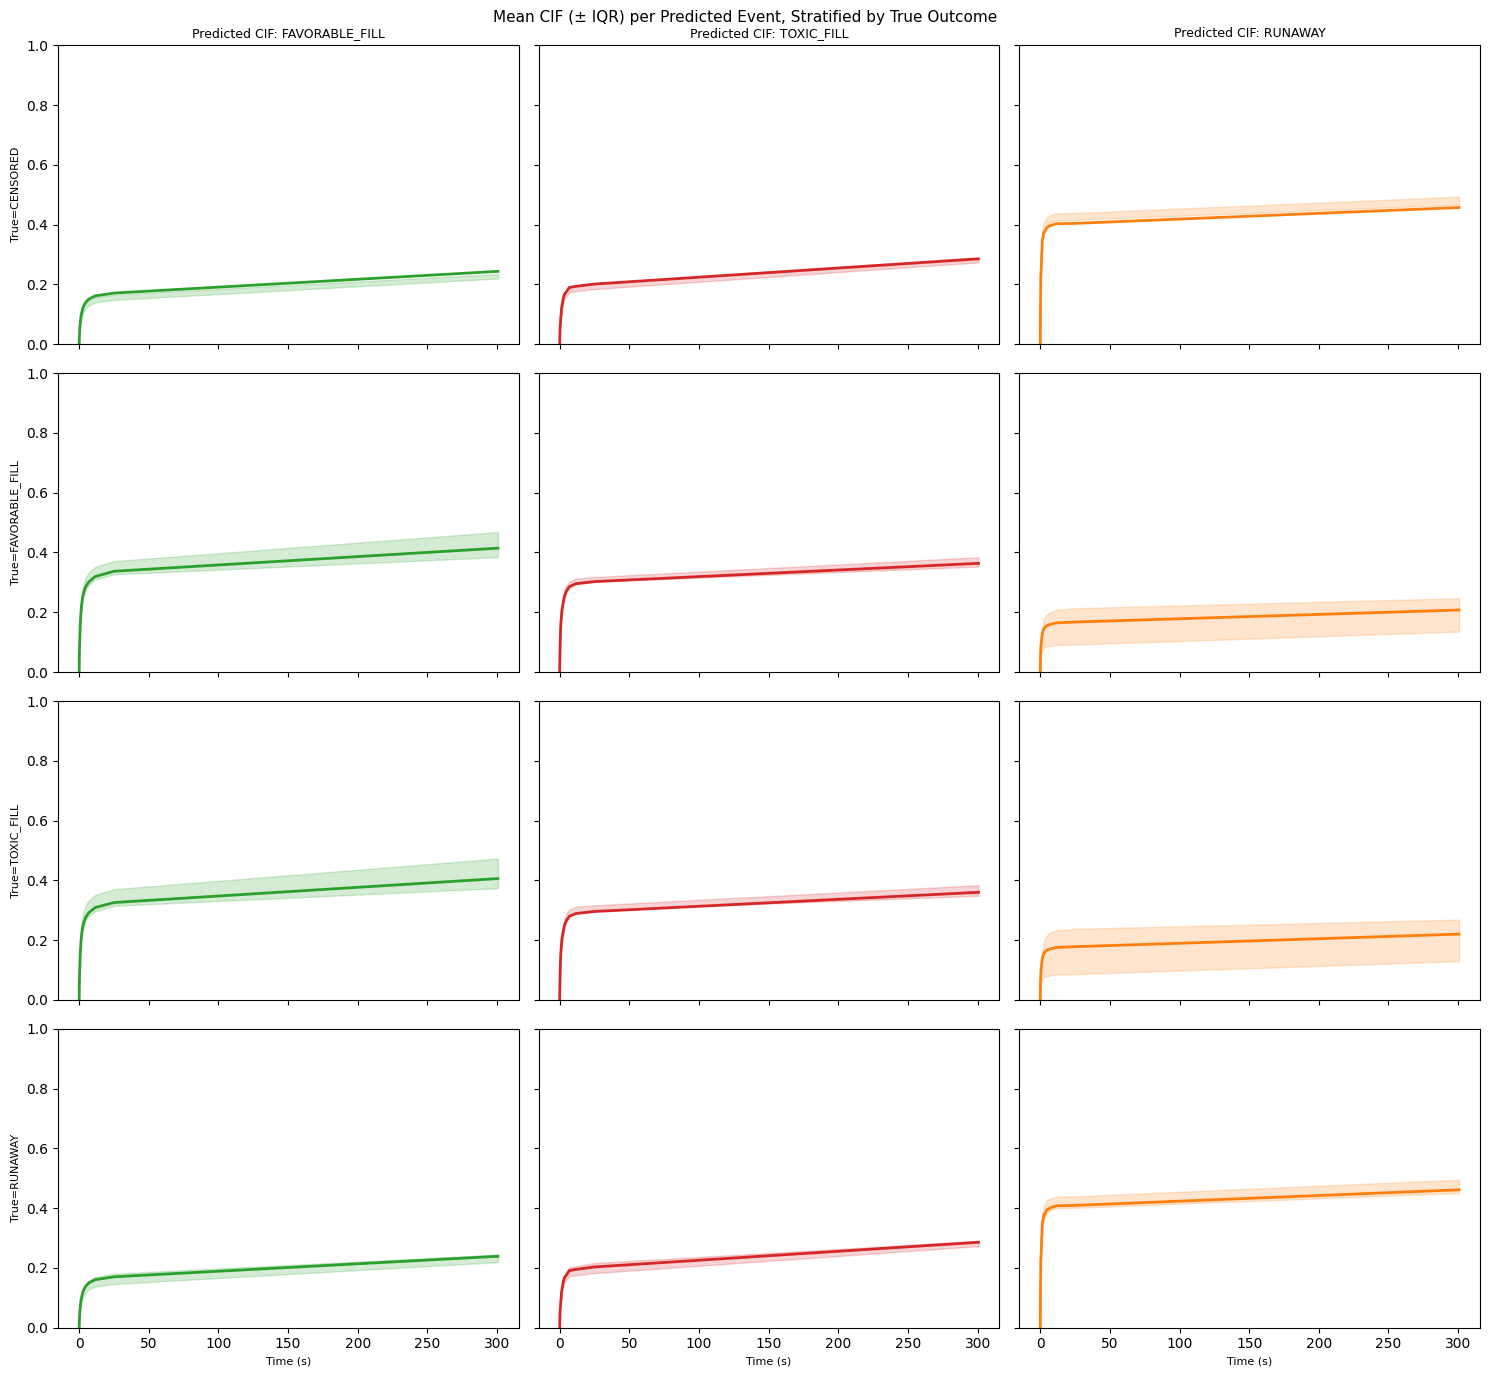

In [263]:
group_labels = [f"True={EventType(c).name}" for c in [0, 1, 2, 3]]
n_groups = len(group_labels)

fig, axes = plt.subplots(n_groups, NUM_COMPETING_EVENTS,
                         figsize=(5 * NUM_COMPETING_EVENTS, 3.5 * n_groups),
                         sharex=True, sharey=True)

for row, true_code in enumerate([0, 1, 2, 3]):
    mask = (D_test == true_code)
    if mask.sum() == 0:
        for col in range(NUM_COMPETING_EVENTS):
            axes[row, col].set_visible(False)
        continue

    for col, pred_name in enumerate(EVENT_NAMES):
        ax = axes[row, col]
        # Separate indexing to avoid NumPy's mixed advanced/basic index transposition:
        # cif_test[col] → (T, N_test), then [:, mask] → (T, n_subset)
        cif_subset = cif_test[col][:, mask]   # (T, n_subset)
        ax.plot(time_grid, cif_subset.mean(axis=1), linewidth=2,
                color=colors[col], label="mean CIF")
        ax.fill_between(
            time_grid,
            np.percentile(cif_subset, 25, axis=1),
            np.percentile(cif_subset, 75, axis=1),
            alpha=0.2, color=colors[col], label="IQR",
        )
        ax.set_ylim(0, 1)
        if row == 0:
            ax.set_title(f"Predicted CIF: {pred_name}", fontsize=9)
        if col == 0:
            ax.set_ylabel(group_labels[row], fontsize=8, rotation=90, labelpad=4)
        if row == n_groups - 1:
            ax.set_xlabel("Time (s)", fontsize=8)

plt.suptitle("Mean CIF (± IQR) per Predicted Event, Stratified by True Outcome", fontsize=11)
plt.tight_layout()
plt.show()

## Summary and Results

| Metric | FAVORABLE_FILL | TOXIC_FILL | RUNAWAY |
|--------|---------------|------------|---------|
| C-td (Antolini) | — | — | — |
| Brier score @ t₂₅ | — | — | — |
| Brier score @ t₅₀ | — | — | — |
| Brier score @ t₇₅ | — | — | — |

*(Fill the table above by reading off the printed values from cells 20 and 22 after running the notebook.)*

### Next Steps
- **Feature engineering**: use only the flattened last LOB snapshot instead of the full sequence, or add scalar features (spread, volume imbalance, time-of-day).
- **Sequence modelling**: replace the MLP backbone with a transformer or LSTM encoder for the lookback dimension (see `demo_deephit_dynamic.ipynb` once built).
- **Hyperparameter search**: tune `alpha`, `sigma`, hidden sizes, dropout, and `NUM_TIME_STEPS`.
- **Cross-validation**: the current train/val/test split is time-agnostic; use a proper temporal walk-forward split to avoid look-ahead bias.